In [1]:
import json
import networkx as nx
from itertools import combinations

In [2]:
with open("wos_CS.json","r") as f:
    data = json.load(f)

In [3]:
def create_network(data):
    G = nx.Graph()
    for item in data:
        keywords = item.get("KW", [])
        for kw1, kw2 in combinations(keywords, 2):
            if G.has_edge(kw1, kw2):
                G[kw1][kw2]["weight"] += 1
            else:
                G.add_edge(kw1, kw2, weight=1)
    return G

In [13]:
import random
import matplotlib.pyplot as plt
def visualize_connected_subgraph(G, num_nodes=10):
    # 获取所有有边的节点
    connected_nodes = set()
    for edge in G.edges():
        connected_nodes.update(edge)  # 将边的两个节点加入集合
    
    # 如果有边的节点数量不足 num_nodes，选择所有
    if len(connected_nodes) < num_nodes:
        selected_nodes = list(connected_nodes)
    else:
        # 从网络中随机选取一条边，扩展到包含 num_nodes 的连通子图
        initial_node = random.choice(list(connected_nodes))
        selected_nodes = {initial_node}
        
        for neighbor in nx.bfs_edges(G, source=initial_node):
            if len(selected_nodes) >= num_nodes:
                break
            selected_nodes.update(neighbor)

    # 获取所选节点的子图
    subgraph = G.subgraph(selected_nodes)
    
    # 绘制子图
    pos = nx.spring_layout(subgraph)  # 使用 spring 布局绘制子图
    nx.draw(subgraph, pos, with_labels=True, node_size=500, font_size=10, node_color='lightblue', arrows=True)
    plt.show()

In [5]:
papers_2010 = []
papers_2011 = []
papers_2012 = []
papers_2013 = []
papers_2014 = []
papers_2015 = []
papers_2016 = []
papers_2017 = []
papers_2018 = []
papers_2019 = []
papers_2020 = []
papers_2021 = []
papers_2022 = []
papers_2023 = []
lists= [papers_2010,papers_2011,papers_2012,papers_2013,papers_2014,papers_2015,papers_2016,papers_2017,papers_2018,papers_2019,papers_2020,papers_2021,papers_2022,papers_2023]
years = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
for item in data:
    dict = {}
    for idx,year in enumerate(years):
        if item["YE"] == year:
            dict["KW"]=item["KW"]
            lists[idx].append(dict)
print("j")

j


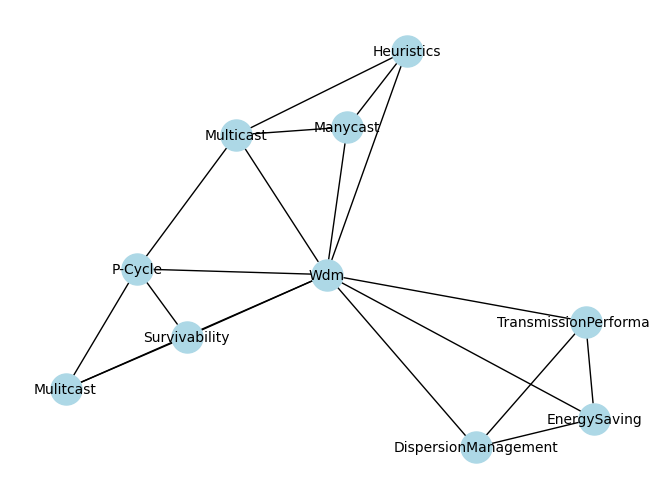

In [14]:
graphs = []
for i in range(14):
    graphs.append(create_network(lists[i]))
visualize_connected_subgraph(graphs[0])
# print(graphs[2])

In [6]:
def return_degree_centrality_list(graph):
    degree_centrality = nx.degree_centrality(graph)  # 返回字典
    degrees = []
    for keyword, degree in degree_centrality.items():
        degrees.append({keyword: degree})
    return degrees

In [7]:
degree_centrality_lists = []
for j in range(14):
    degree_centrality_lists.append(return_degree_centrality_list(graphs[j]))
# print(degree_centrality_lists[1])
print("j")

j


In [8]:
keyword_together_degree = {}
for idx,year_data in enumerate(degree_centrality_lists):
    for entry in year_data:
        for kw,degree_c in entry.items():
            if kw not in keyword_together_degree:
                keyword_together_degree[kw] = [0]*14
            keyword_together_degree[kw][idx] = degree_c
with open("keyword_together_degree.json","w") as f1:
    json.dump(keyword_together_degree,f1,indent=4,ensure_ascii=False)
print("j")

j
